## Imports and Global Variables

In [2]:
import numpy as np
import cv2
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt

input_folder_path = "../media/input"
output_folder_path = "../media/output"
epsilon = 1e-10

# NOTE: Please always maintain the order of T, N, D while processing as well as passing parameters to functions

## Reading Input Image and Feature Maps

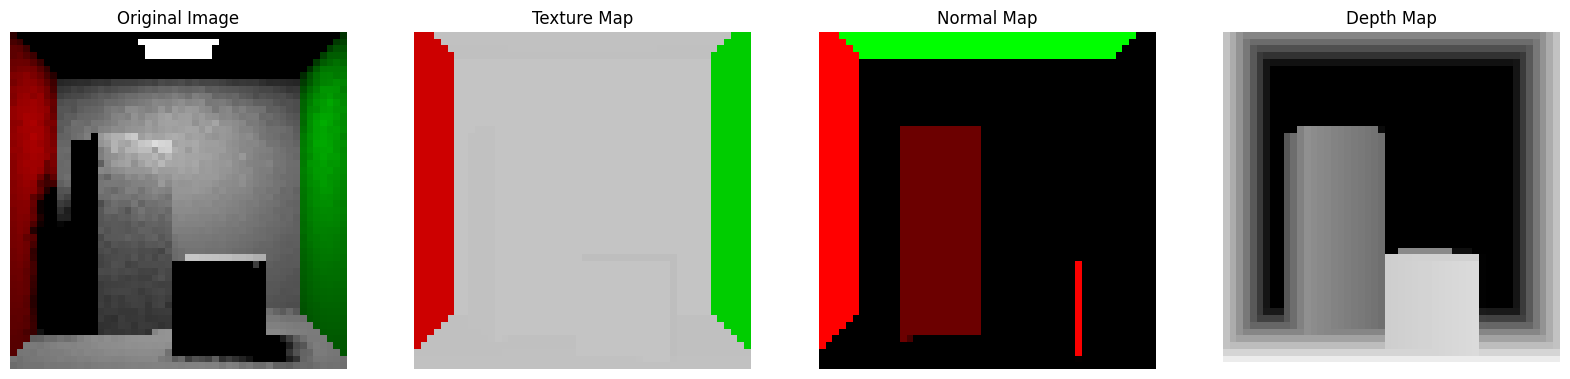

In [3]:
a = 50
n = 100 # Sampling Rate

# Note: We are resizing the images to 200x200 for faster processing (will remove later when everything is working)
noisy_image = cv2.resize(cv2.imread(input_folder_path + "/cuboids/100.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0       # Noisy Image
noisy_image_bgr = cv2.resize(cv2.imread(input_folder_path + "/cuboids/100.png"), (a, a))
noisy_image_rgb = cv2.cvtColor(noisy_image_bgr, cv2.COLOR_BGR2RGB) / 255.0

texture_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/texture.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0   # Texture Map
texture_map_bgr = cv2.resize(cv2.imread(input_folder_path + "/cuboids/texture.png"), (a, a))
texture_map_rgb = cv2.cvtColor(texture_map_bgr, cv2.COLOR_BGR2RGB) / 255.0

normal_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/normal.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0     # Normal Map
normal_map_bgr = cv2.resize(cv2.imread(input_folder_path + "/cuboids/normal.png"), (a, a))
normal_map_rgb = cv2.cvtColor(normal_map_bgr, cv2.COLOR_BGR2RGB) / 255.0

depth_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/depth.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0       # Depth Map

# Plotting the image and feature maps
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(noisy_image_rgb)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(texture_map_rgb)
axs[1].set_title("Texture Map")
axs[1].axis('off')

axs[2].imshow(normal_map_rgb)
axs[2].set_title("Normal Map")
axs[2].axis('off')

axs[3].imshow(depth_map, cmap='gray')
axs[3].set_title("Depth Map")
axs[3].axis('off')

plt.show()

## Feature Maps Prefiltering

In [4]:
def sobel_gradient(image):
    """Calculate gradient magnitude using Sobel operator."""
    Gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal gradients
    Gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Vertical gradients
    gradient_magnitude = np.sqrt(Gx**2 + Gy**2)
    return gradient_magnitude

def guided_image_filter(I, P, radius=7, eps=0.001):
    """Apply guided image filtering."""
    mean_I = cv2.boxFilter(I, -1, (radius, radius))
    mean_P = cv2.boxFilter(P, -1, (radius, radius))
    mean_I_P = cv2.boxFilter(I * P, -1, (radius, radius))
    cov_I_P = mean_I_P - mean_I * mean_P
    
    mean_II = cv2.boxFilter(I * I, -1, (radius, radius))
    var_I = mean_II - mean_I * mean_I
    
    a = cov_I_P / (var_I + eps)
    b = mean_P - a * mean_I
    
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))
    
    output = mean_a * I + mean_b
    return output

def prefilter_features(texture_map, normal_map, depth_map):
    """Prefilter noisy features using the guided image filter."""
    # Normalise the normal map before calculating the gradients
    # texture_map = texture_map / 255.0
    # normal_map = normal_map / 255.0
    # normal_map_x = normal_map[:, :, 0] / 255.0
    # normal_map_y = normal_map[:, :, 1] / 255.0
    # normal_map_z = normal_map[:, :, 2] / 255.0
    # depth_map = depth_map / 255.0

    # Calculate gradients for each feature map
    gradient_texture = sobel_gradient(texture_map)
    gradient_normal = sobel_gradient(normal_map)
    # gradient_normal_x = sobel_gradient(normal_map_x)
    # gradient_normal_y = sobel_gradient(normal_map_y)
    # gradient_normal_z = sobel_gradient(normal_map_z)
    gradient_depth = sobel_gradient(depth_map)
    
    # Combine gradients to get a robust guidance image
    combined_gradient = np.maximum.reduce([gradient_texture, gradient_normal, gradient_depth])
    # combined_gradient = np.maximum.reduce([gradient_texture, gradient_normal_x, gradient_normal_y, gradient_normal_z, gradient_depth])
    
    # Filter each feature map using the guided image filter
    filtered_texture = np.clip(guided_image_filter(combined_gradient, texture_map), 0, 1)
    filtered_normal = np.clip(guided_image_filter(combined_gradient, normal_map), 0, 1)
    # filtered_normal_x = np.clip(guided_image_filter(combined_gradient, normal_map_x), 0, 1)
    # filtered_normal_y = np.clip(guided_image_filter(combined_gradient, normal_map_y), 0, 1)
    # filtered_normal_z = np.clip(guided_image_filter(combined_gradient, normal_map_z), 0, 1)
    filtered_depth = np.clip(guided_image_filter(combined_gradient, depth_map), 0, 1)

    # Converting filters back to 0-255 range
    filtered_texture = (filtered_texture * 255).astype(np.uint8)
    filtered_normal = (filtered_normal * 255).astype(np.uint8)
    # filtered_normal_x = (filtered_normal_x * 255).astype(np.uint8)
    # filtered_normal_y = (filtered_normal_y * 255).astype(np.uint8)
    # filtered_normal_z = (filtered_normal_z * 255).astype(np.uint8)
    # filtered_normal = np.dstack((filtered_normal_x, filtered_normal_y, filtered_normal_z))
    filtered_depth = (filtered_depth * 255).astype(np.uint8)
    
    return combined_gradient, filtered_texture, filtered_normal, filtered_depth

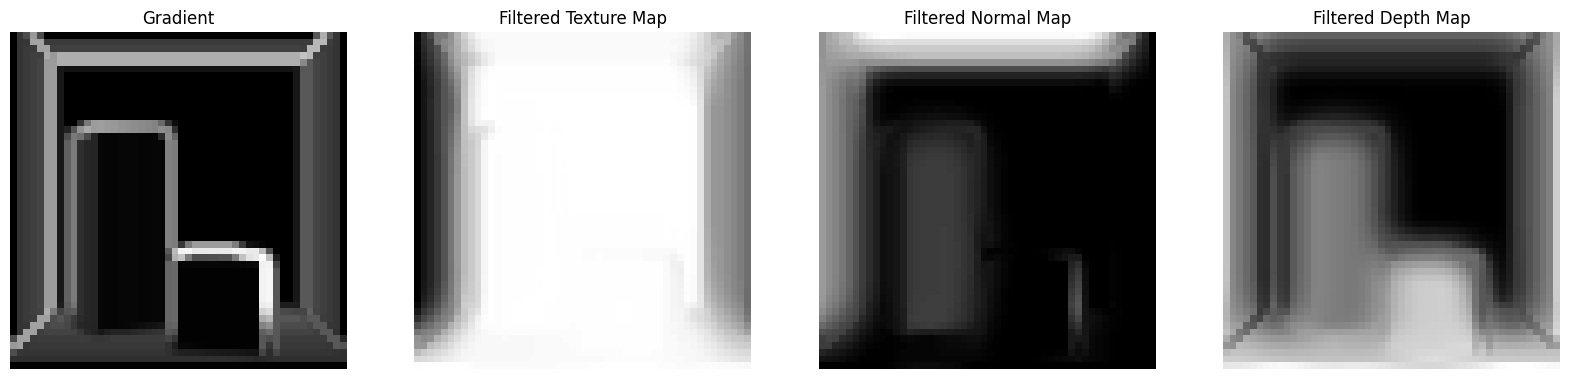

In [5]:
gradient_map, filtered_texture, filtered_normal, filtered_depth = prefilter_features(texture_map, normal_map, depth_map)

# Plotting the image and prefiltered feature maps
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(gradient_map, cmap='gray')
axs[0].set_title("Gradient")
axs[0].axis('off')

axs[1].imshow(filtered_texture, cmap='gray')
axs[1].set_title("Filtered Texture Map")
axs[1].axis('off')

axs[2].imshow(filtered_normal, cmap='gray')
axs[2].set_title("Filtered Normal Map")
axs[2].axis('off')

axs[3].imshow(filtered_depth, cmap='gray')
axs[3].set_title("Filtered Depth Map")
axs[3].axis('off')

plt.show()

## Cross Bilateral Filter

In [6]:
def feature_distance(f1, f2, grad_i, var_f1, var_f2):
    nr = np.linalg.norm(f1 - f2)**2
    dr = np.float32(var_f1)**2 + np.float32(var_f2)**2 + np.minimum(grad_i, 0.001) + epsilon
    dist = nr / dr
    return dist

def calculate_single_channel_variance(image, kernel_size=3):
    # Helper function to calculate sample variance
    def sample_variance(window):
        return np.var(window, ddof=1)  # Sample variance

    # Calculate variance for the image
    variance = generic_filter(image, sample_variance, size=kernel_size)
    return variance

def calculate_neighborhood_variances(texture_map, normal_map, depth_map, kernel_size=3):
    # Calculate variance for the texture map
    texture_variance = calculate_single_channel_variance(texture_map, kernel_size)

    # Calculate variance for each component of the normal map
    normal_variance = calculate_single_channel_variance(normal_map, kernel_size)
    # normal_x_variance = calculate_single_channel_variance(normal_map[:, :, 0], kernel_size)
    # normal_y_variance = calculate_single_channel_variance(normal_map[:, :, 1], kernel_size)
    # normal_z_variance = calculate_single_channel_variance(normal_map[:, :, 2], kernel_size)

    # Combine the variances of the normal components
    # normal_variance = (normal_x_variance + normal_y_variance + normal_z_variance) / 3

    # Calculate variance for the depth map
    depth_variance = calculate_single_channel_variance(depth_map, kernel_size)

    return texture_variance, normal_variance, depth_variance

def calc_filter_weight(image, texture_map, normal_map, depth_map, texture_variance, normal_variance, depth_variance, grad, alpha, beta, gamma_t, gamma_d, gamma_n, i, j, x, y):
    # H, W, C = image.shape
    H, W = image.shape
    spatial_coords = np.indices((H, W)).transpose(1, 2, 0)  # Pixel coordinates
    
    # Spatial weight
    spatial_weight = np.exp(-np.linalg.norm(spatial_coords[i, j] - spatial_coords[x, y])**2 / (2 * alpha[i, j]**2 + epsilon))

    # Color weight
    color_weight = np.exp(-np.linalg.norm(np.float32(image[i, j]) - np.float32(image[x, y]))**2 / (2 * beta[i, j]**2 + epsilon))

    # Texture weight
    texture_weight = np.exp(-feature_distance(np.float32(texture_map[i, j]), np.float32(texture_map[x, y]), grad[x, y], texture_variance[i, j], texture_variance[x, y])**2 / (2 * gamma_t[i, j]**2 + epsilon))

    # Normal weight
    normal_weight = np.exp(-feature_distance(np.float32(normal_map[i, j]), np.float32(normal_map[x, y]), grad[x, y], normal_variance[i, j], normal_variance[x, y])**2 / (2 * gamma_n[i, j]**2 + epsilon))
    
    # Depth weight
    depth_weight = np.exp(-feature_distance(np.float32(depth_map[i, j]), np.float32(depth_map[x, y]), grad[x, y], depth_variance[i, j], depth_variance[x, y])**2 / (2 * gamma_d[i, j]**2 + epsilon))

    # Total weight
    weight = spatial_weight * color_weight * texture_weight * depth_weight * normal_weight
    return weight

In [7]:
def calc_neighbourhood(i, j, H, W):
    return [(x, y) for x in range(max(0, i-1), min(H, i+2))
                   for y in range(max(0, j-1), min(W, j+2))]

def cross_bilateral_filter(image, texture_map, normal_map, depth_map, alpha, beta, gamma_t, gamma_d, gamma_n, grad):
    # H, W, C = image.shape
    H, W = image.shape
    filtered_image = np.zeros_like(image)

    for i in range(H):
        for j in range(W):
            neighborhood = calc_neighbourhood(i, j, H, W)

            # numerator = np.zeros(C)
            numerator = 0
            denominator = 0

            texture_variance, normal_variance, depth_variance = calculate_neighborhood_variances(texture_map, normal_map, depth_map)

            for x, y in neighborhood:
                d_ij = calc_filter_weight(image, texture_map, normal_map, depth_map, texture_variance, normal_variance, depth_variance, grad, alpha, beta, gamma_t, gamma_d, gamma_n, i, j, x, y)

                numerator += d_ij * image[x, y]
                denominator += d_ij

            # Filtered pixel value
            filtered_image[i, j] = numerator / denominator if denominator != 0 else image[i, j]

    return filtered_image

## Calculating Parameters

### Optimising $\alpha$ (Spatial Parameter)

In [21]:
# Values taken from research paper
alpha_vals = np.array([0.1 * np.ones(noisy_image.shape[:2]), 1 * np.ones(noisy_image.shape[:2]), 2 * np.ones(noisy_image.shape[:2]), 4 * np.ones(noisy_image.shape[:2]), 8 * np.ones(noisy_image.shape[:2])])
# alpha_vals = np.array([0.1 * np.ones(noisy_image.shape[:2])])

beta = 0 * np.ones(noisy_image.shape[:2])

# Keep gamma constant for calculation of alpha_optimal
gamma_t = 0.2 * np.ones(noisy_image.shape[:2])
gamma_d = 0.3 * np.ones(noisy_image.shape[:2])
gamma_n = 0.4 * np.ones(noisy_image.shape[:2])

def compute_bias_and_variance_per_pixel(image, texture_map, normal_map, depth_map, grad, alpha, beta, gamma_t, gamma_n, gamma_d, i, j):
    H, W = image.shape[:2]  # Get the dimensions of the image
    neighborhood = calc_neighbourhood(i, j, H, W)
    
    # Initialize variables for bias and variance calculations
    numerator = 0
    denominator = 0
    variance_sum = 0

    c_i = image[i, j]  # Central pixel intensity or value
    texture_variance, normal_variance, depth_variance = calculate_neighborhood_variances(texture_map, normal_map, depth_map)

    for x, y in neighborhood:
        d_ij = calc_filter_weight(image, texture_map, normal_map, depth_map, texture_variance, normal_variance, depth_variance, grad,
                                  alpha, beta, gamma_t, gamma_n, gamma_d, i, j, x, y)
        c_j = image[x, y]  # Intensity or value of neighbor pixel
        var_j = grad[x, y]  # Variance term for the neighbor pixel (e.g., from gradient)

        numerator += d_ij * c_j
        denominator += d_ij
        variance_sum += (d_ij ** 2) * var_j

    # Compute bias
    bias = np.mean((numerator / denominator) - c_i if denominator != 0 else 0)

    # Compute variance
    variance = variance_sum

    return bias, variance

def fit_curve_bias(alphas, biases):
    # Linear regression to fit for b0 and b1
    x = np.array(alphas)
    y = np.array(biases)

    # Calculate the mean of x and y
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    b1 = np.sum((x - mean_x) * (y - mean_y)) / np.sum((x - mean_x)**2)
    b0 = mean_y - b1 * mean_x

    return b0, b1

def fit_curve_variance(alpha_vals, variances, n):
    x = np.array(alpha_vals)
    y = np.array(variances)

    # Transform x into z = 1 / x^2
    z = 1 / (x**2 + epsilon)

    # Transform y to match the equation n(i) * y = b0 + b1 * z
    y_transformed = n * y

    # Perform linear regression for y_transformed = b0 + b1 * z
    mean_z = np.mean(z)
    mean_y_transformed = np.mean(y_transformed)

    v1 = np.sum((z - mean_z) * (y_transformed - mean_y_transformed)) / np.sum((z - mean_z)**2)
    v0 = mean_y_transformed - v1 * mean_z

    return v0, v1

def calculate_optimal_spatial_parameter(image, texture_map, normal_map, depth_map, grad, n, alpha_vals, beta, gamma_t, gamma_n, gamma_d):
    biases = np.zeros_like(alpha_vals)
    variances = np.zeros_like(alpha_vals)

    for idx, alpha in enumerate(alpha_vals):
        filtered_image = cross_bilateral_filter(image, texture_map, normal_map, depth_map, alpha, beta, gamma_t, gamma_n, gamma_d, grad)
        for i in range(filtered_image.shape[0]):
            for j in range(filtered_image.shape[1]):
                biases[idx, i, j], variances[idx, i, j] = compute_bias_and_variance_per_pixel(image, texture_map, normal_map, depth_map, grad, alpha, beta, gamma_t, gamma_n, gamma_d, i, j)

    # Fitting parametric curves to the bias and variance values
    b0 = np.zeros(filtered_image.shape[:2])
    b1 = np.zeros(filtered_image.shape[:2])
    v0 = np.zeros(filtered_image.shape[:2])
    v1 = np.zeros(filtered_image.shape[:2])

    for i in range(filtered_image.shape[0]):
        for j in range(filtered_image.shape[1]):
            b0[i, j], b1[i, j] = fit_curve_bias(alpha_vals[:, i, j], np.array(biases[:, i, j]))
            v0[i, j], v1[i, j] = fit_curve_variance(alpha_vals[:, i, j], np.array(variances[:, i, j]), n)

    alpha_op = np.power(np.abs(v1 / (2 * b1**2 * n + epsilon)), 1/6)
    return alpha_op

alpha_op = calculate_optimal_spatial_parameter(noisy_image, filtered_texture, filtered_normal, filtered_depth, gradient_map, n, alpha_vals, beta, gamma_t, gamma_n, gamma_d)

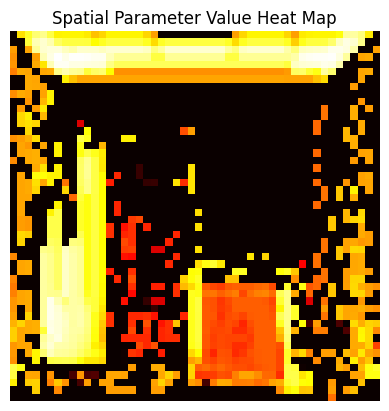

In [24]:
plt.imshow(alpha_op, cmap='hot', interpolation='nearest')
plt.axis('off')
plt.title("Spatial Parameter Value Heat Map")
plt.show()

## Optimising $\gamma$ (Feature Parameters)

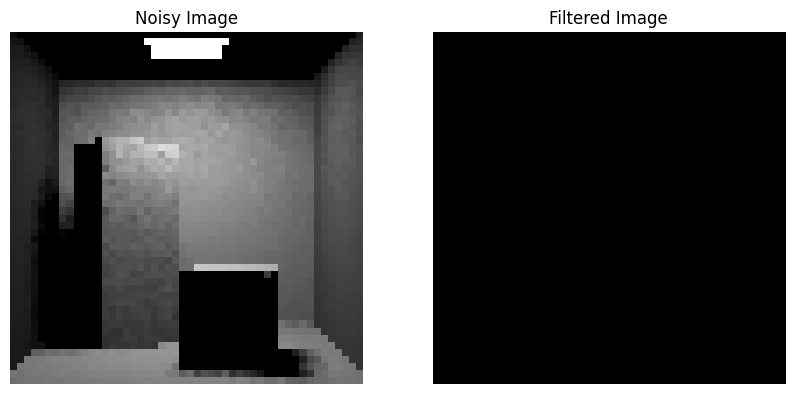

In [22]:
def calc_feature_parameters(image, texture_map, normal_map, depth_map, alpha_op, s_vals):
    guided_filtered_image_t = guided_image_filter(image, texture_map)
    guided_filtered_image_n = guided_image_filter(image, normal_map)
    guided_filtered_image_d = guided_image_filter(image, depth_map)

    lambda_t = np.abs(guided_filtered_image_t - image) / (image + epsilon)
    lambda_n = np.abs(guided_filtered_image_n - image) / (image + epsilon)
    lambda_d = np.abs(guided_filtered_image_d - image) / (image + epsilon)

    ref_image = np.zeros_like(image)

    # Create a boolean mask for each condition
    condition_t = (lambda_t < lambda_n) & (lambda_t < lambda_d)
    condition_n = (lambda_n < lambda_t) & (lambda_n < lambda_d)
    condition_d = ~(condition_t | condition_n)  # Remaining condition

    # Initialize ref_image with zeros or a suitable default value
    ref_image = np.zeros_like(guided_filtered_image_t)

    # Use the masks to assign values from the appropriate guided filtered images
    ref_image[condition_t] = guided_filtered_image_t[condition_t]
    ref_image[condition_n] = guided_filtered_image_n[condition_n]
    ref_image[condition_d] = guided_filtered_image_d[condition_d]

    errors = np.zeros((len(s_vals), image.shape[0], image.shape[1]))

    for idx, s in enumerate(s_vals):
        c_j_hat = cross_bilateral_filter(image, filtered_texture, filtered_normal, filtered_depth, alpha_op, beta, s, s, s, gradient_map)
        errors[idx] = (np.abs(c_j_hat - ref_image) ** 2) / (ref_image ** 2 + epsilon)

    return errors

def two_step_smoothening(image, errors):
    l = errors.shape[0]  # Number of steps or levels in the process
    
    for j in range(l):
        errors[j] = guided_image_filter(errors[j], errors[j])  # Apply guidance on the error term
    
    binaries = list()
    for err in errors:
        min_err = np.min(err)
        binary = np.where(err == min_err, 1, 0)
    
    wei_j = list()
    for binary in binaries:
        wei_j.append(guided_image_filter(binary, binary))
    
    nr = np.zeros_like(image)
    dr = np.zeros_like(image)

    for wei in wei_j:
        nr += wei * image
        dr += wei
    
    out_i = nr / (dr + epsilon)
    return out_i
            
s_vals = [0.25 * np.ones(noisy_image.shape[:2]), 0.6 * np.ones(noisy_image.shape[:2]), 0.8 * np.ones(noisy_image.shape[:2])]

errors = calc_feature_parameters(noisy_image, filtered_texture, filtered_normal, filtered_depth, alpha_op, s_vals)
out_i = two_step_smoothening(noisy_image, errors)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(noisy_image, cmap='gray')
ax[0].set_title("Noisy Image")
ax[0].axis('off')

ax[1].imshow(out_i, cmap='gray')
ax[1].set_title("Filtered Image")
ax[1].axis('off')

plt.show()

## Size of Image vs Time Plot

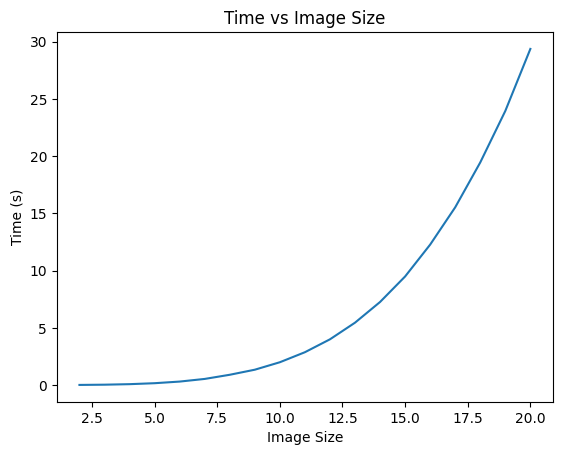

In [80]:
import time
times = list()

x_axis = range(2, 21)

for a in x_axis:
    noisy_image = cv2.resize(cv2.imread(input_folder_path + "/cuboids/100.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0       # Noisy Image
    texture_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/texture.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0   # Texture Map
    normal_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/normal.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0     # Normal Map
    depth_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/depth.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0       # Depth Map
    gradient_map, filtered_texture, filtered_normal, filtered_depth = prefilter_features(texture_map, normal_map, depth_map)
    
    start = time.time()
    alpha_op = calculate_optimal_spatial_parameter(noisy_image, filtered_texture, filtered_normal, filtered_depth, gradient_map, n, alpha_vals, beta, gamma_t, gamma_n, gamma_d)
    end = time.time()
    times.append(end - start)

plt.plot(x_axis, times)
plt.xlabel("Image Size")
plt.ylabel("Time (s)")
plt.title("Time vs Image Size")
plt.show()

## Saving the value of alpha for 50x50 cuboids image for future use

In [ ]:
with open("alpha_value.txt", "w") as f:
    for i in range(alpha_op.shape[0]):
        for j in range(alpha_op.shape[1]):
            f.write(str(alpha_op[i, j]) + " ")

In [12]:
def read_alpha_values(file_path, shape):
    with open(file_path, "r") as f:
        values = np.array([float(val) for val in f.read().split()])
    return values.reshape(shape)

alpha_op = read_alpha_values("alpha_value.txt", noisy_image.shape)
beta = 10000 * np.ones(noisy_image.shape[:2])
gamma_t = 0.2 * np.ones(noisy_image.shape[:2])
gamma_d = 0.3 * np.ones(noisy_image.shape[:2])
gamma_n = 0.4 * np.ones(noisy_image.shape[:2])
filtered_image = cross_bilateral_filter(noisy_image, filtered_texture, filtered_normal, filtered_depth, alpha_op * 500000, beta, gamma_t, gamma_d, gamma_n, gradient_map)

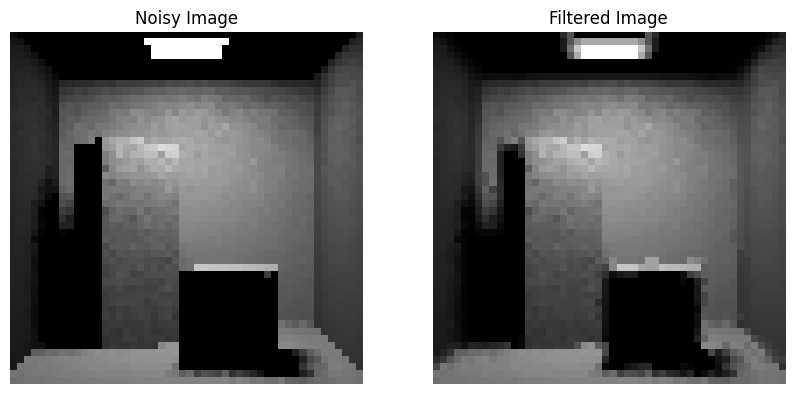

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(noisy_image, cmap='gray')
ax[0].set_title("Noisy Image")
ax[0].axis('off')

ax[1].imshow(filtered_image, cmap='gray')
ax[1].set_title("Filtered Image")
ax[1].axis('off')

plt.show()